AI BASED WORKFORCE ANALYTICS DASHBOARD
Exploratory Data Analysis (EDA) 

In [ ]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
 
sns.set_style("whitegrid")
 
csv_file = Path.cwd() / "employee_attrition_cleaned_dataset.csv"
df = pd.read_csv(csv_file)

#Data Quality Check
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nStatistical Summary:\n", df.describe())

Dataset Shape: (15000, 32)

Data Types:
 employee_id                    int64
age                            int64
gender                        object
marital_status                object
education_level               object
department                    object
job_role                      object
employment_type               object
years_at_company               int64
years_in_current_role          int64
monthly_income                 int64
salary_hike_percent          float64
job_level                      int64
performance_rating             int64
job_satisfaction               int64
work_life_balance              int64
environment_satisfaction       int64
relationship_satisfaction      int64
training_hours_last_year       int64
overtime                       int64
remote_work                    int64
business_travel               object
distance_from_home             int64
commute_time_minutes           int64
number_of_projects             int64
team_size                      int

Overall Attrition

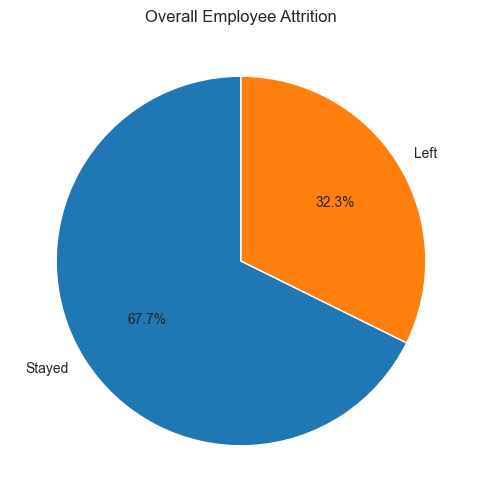

In [4]:
attrition_counts = df["attrition"].value_counts()
 
plt.figure(figsize=(6, 6))
plt.pie(
    attrition_counts,
    labels=["Stayed", "Left"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Overall Employee Attrition")
plt.show()

INSIGHT:The overall attrition rate is 32.3%, meaning approximately one in every three employees has left the organization. This represents a significant employee-retention concern.

Work-Arrangement Factors vs Attrition
Overtime, remote work, promotion history, business travel, and employment type are grouped together below since each is a simple category-level comparison.

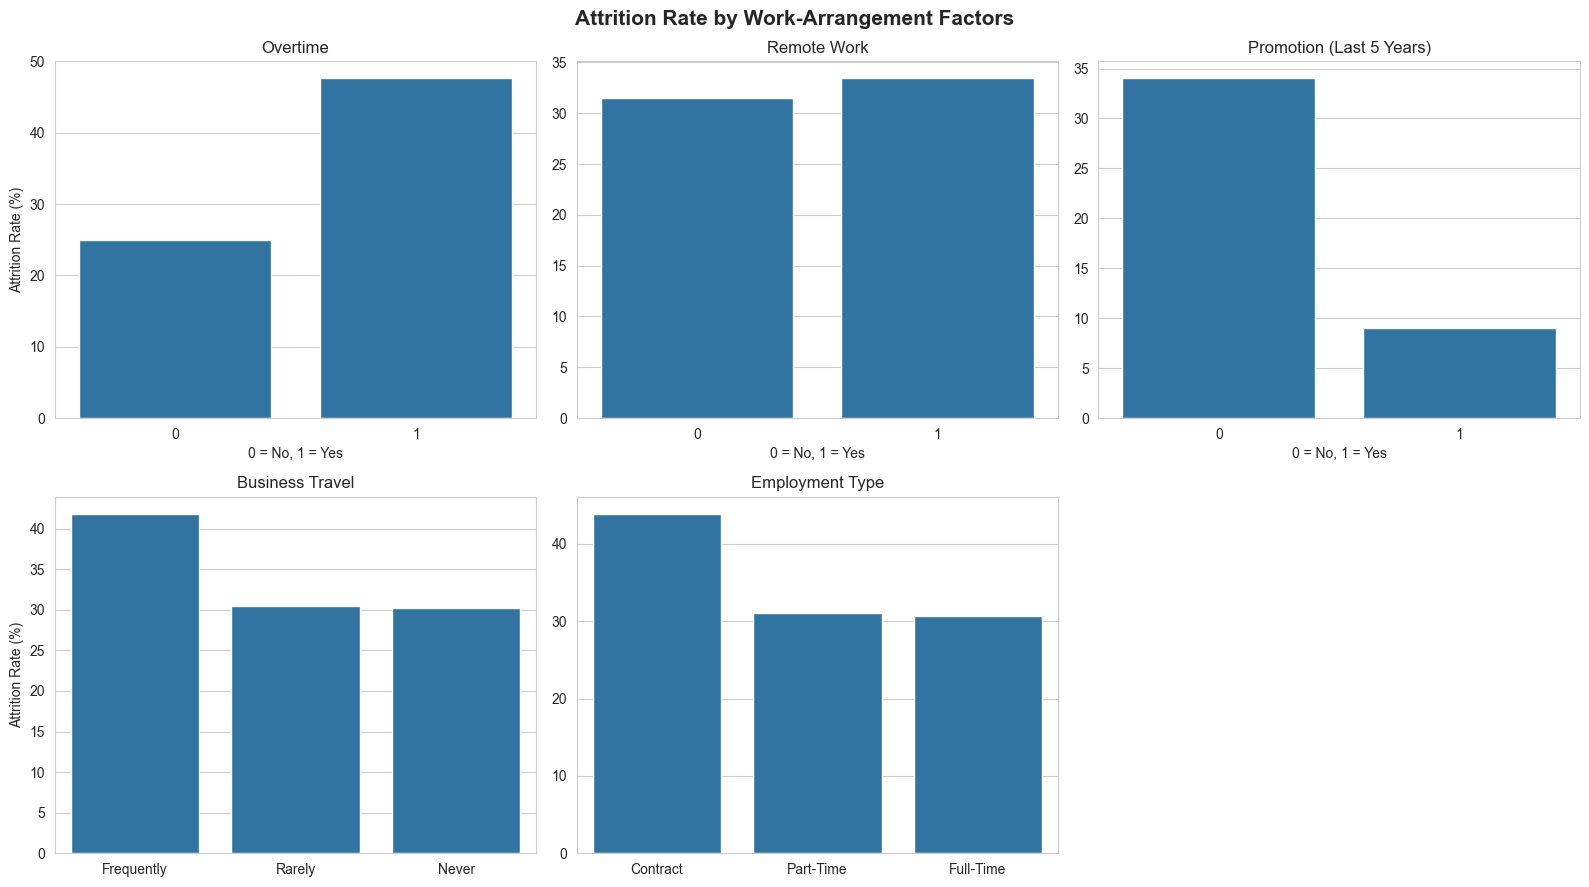

In [5]:
overtime_attrition    = df.groupby("overtime")["attrition"].mean() * 100
remote_attrition      = df.groupby("remote_work")["attrition"].mean() * 100
promotion_attrition   = df.groupby("promotion_last_5_years")["attrition"].mean() * 100
travel_attrition      = (df.groupby("business_travel")["attrition"].mean() * 100).sort_values(ascending=False)
employment_attrition  = (df.groupby("employment_type")["attrition"].mean() * 100).sort_values(ascending=False)
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
 
sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values, ax=axes[0, 0])
axes[0, 0].set_title("Overtime")
axes[0, 0].set_xlabel("0 = No, 1 = Yes")
axes[0, 0].set_ylabel("Attrition Rate (%)")
 
sns.barplot(x=remote_attrition.index, y=remote_attrition.values, ax=axes[0, 1])
axes[0, 1].set_title("Remote Work")
axes[0, 1].set_xlabel("0 = No, 1 = Yes")
axes[0, 1].set_ylabel("")
 
sns.barplot(x=promotion_attrition.index, y=promotion_attrition.values, ax=axes[0, 2])
axes[0, 2].set_title("Promotion (Last 5 Years)")
axes[0, 2].set_xlabel("0 = No, 1 = Yes")
axes[0, 2].set_ylabel("")
 
sns.barplot(x=travel_attrition.index, y=travel_attrition.values, ax=axes[1, 0])
axes[1, 0].set_title("Business Travel")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Attrition Rate (%)")
 
sns.barplot(x=employment_attrition.index, y=employment_attrition.values, ax=axes[1, 1])
axes[1, 1].set_title("Employment Type")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")
 
axes[1, 2].axis("off")
 
fig.suptitle("Attrition Rate by Work-Arrangement Factors", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

InsightS:
1) Employees who work overtime have an attrition rate of 47.62%, compared with only 25.02% among employees who do not work overtime, a difference of approximately 22.6 percentage points.
2) Remote work shows almost no effect (33.43% vs 31.48%) and is not a meaningful driver on its own.
3) Promotion history shows an even larger gap: employees promoted within the last five years have an attrition rate of just 8.98%, compared with 34.02% for employees who were not promoted.
4) employees who travel frequently leave at 41.84%, well above those who travel rarely (30.44%) or never (30.21%)
5) Contract employees leave at 43.9%, noticeably higher than Full-Time (30.7%) or Part-Time (31.1%) staff.

Rating-Scale Factors vs Attrition
Job satisfaction, work-life balance, and job level are all scored on a 1-5 scale, so they are compared together below.

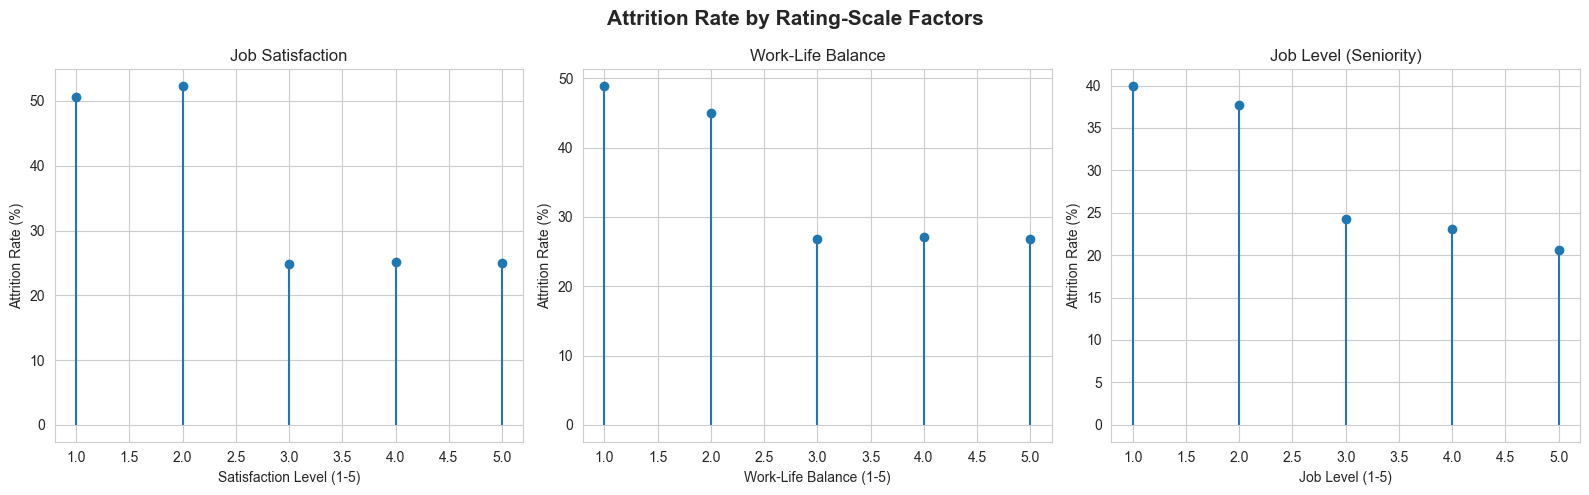

In [6]:
satisfaction_attrition = df.groupby("job_satisfaction")["attrition"].mean() * 100
wlb_attrition           = df.groupby("work_life_balance")["attrition"].mean() * 100
job_level_attrition     = df.groupby("job_level")["attrition"].mean() * 100
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
for ax, series, title, xlabel in zip(
    axes,
    [satisfaction_attrition, wlb_attrition, job_level_attrition],
    ["Job Satisfaction", "Work-Life Balance", "Job Level (Seniority)"],
    ["Satisfaction Level (1-5)", "Work-Life Balance (1-5)", "Job Level (1-5)"]
):
    ax.stem(series.index, series.values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Attrition Rate (%)")
 
fig.suptitle("Attrition Rate by Rating-Scale Factors", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

Insights:
1) Attrition is substantially higher among employees with low job satisfaction. Satisfaction levels 1 and 2 show attrition rates of 50.55%  and 52.26% respectively, roughly double the ~25% rate seen at levels 3-5.
2) Work-life balance follows a similar pattern, with the lowest rating showing 48.85% attrition compared with approximately 27% for ratings 3-5.
3) Job level shows a clear downward trend, with attrition highest among the most junior employees and decreasing steadily as seniority increases, consistent with the tenure and promotion findings elsewhere in this analysis.

Attrition by Department

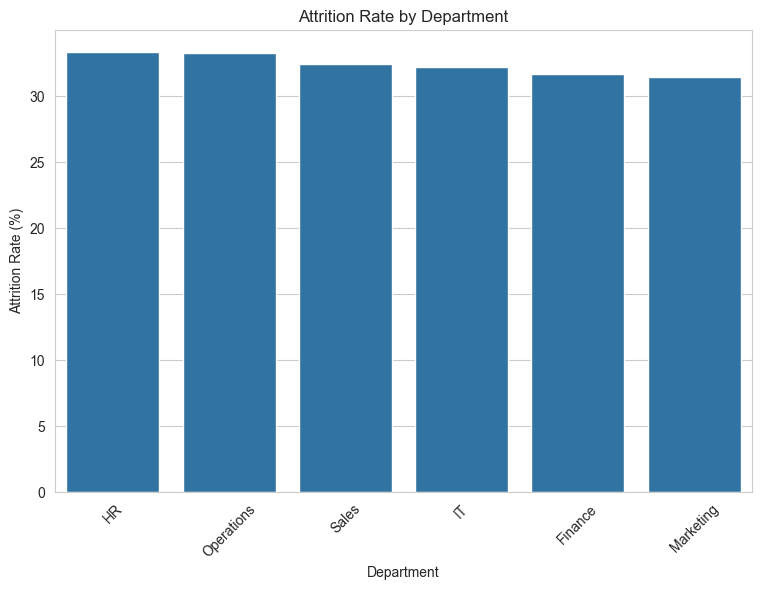

In [7]:
department_attrition = (
    df.groupby("department")["attrition"].mean().sort_values(ascending=False) * 100
)
 
plt.figure(figsize=(9, 6))
sns.barplot(x=department_attrition.index, y=department_attrition.values)
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

Insight: HR has the highest attrition rate at 33.31%, closely followed by Operations at 33.24%. Marketing has the lowest attrition rate at 31.42%. The difference between departments is relatively small, suggesting that attrition is an organization-wide issue rather than one concentrated in a single department.

Attrition by Job Role

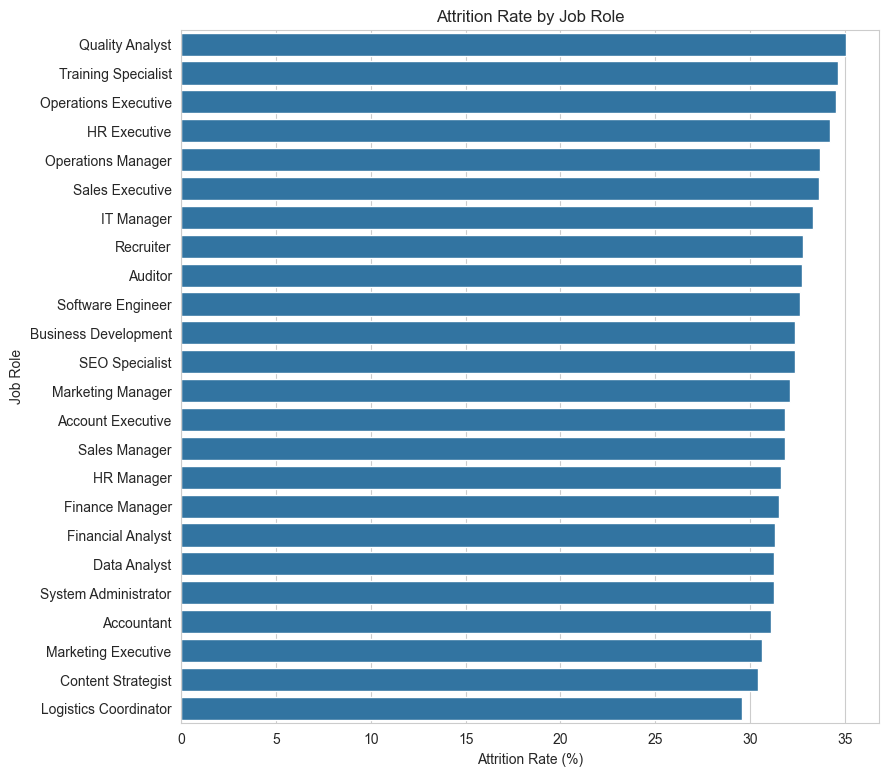

In [8]:
role_attrition = (
    df.groupby("job_role")["attrition"].mean().mul(100).sort_values(ascending=False)
)
 
plt.figure(figsize=(9, 9))
sns.barplot(x=role_attrition.values, y=role_attrition.index)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.show()

Insight:Quality Analyst (35.05%), Training Specialist (34.67%), and Operations Executive (34.54%) are the highest-attrition roles, while Logistics Coordinator (29.60%) is the lowest. The spread across roles is wider than the spread across departments, indicating that role-level retention initiatives are likely to be more effective than department-level ones.
 

Tenure, Pay, and Risk Score vs Attrition

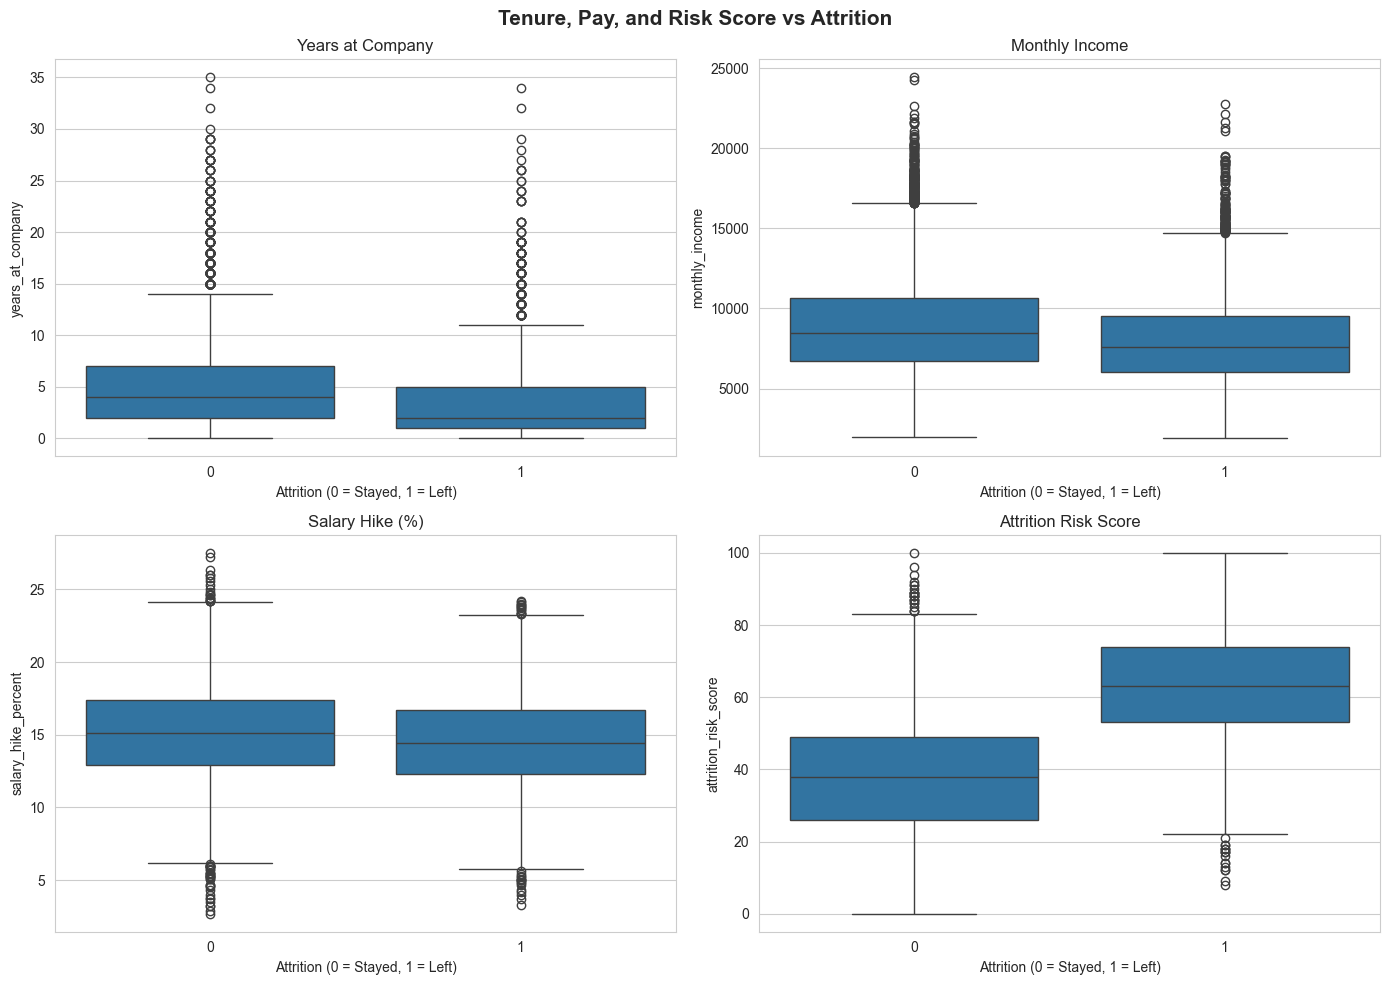

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
sns.boxplot(data=df, x="attrition", y="years_at_company", ax=axes[0, 0])
axes[0, 0].set_title("Years at Company")
axes[0, 0].set_xlabel("Attrition (0 = Stayed, 1 = Left)")
 
sns.boxplot(data=df, x="attrition", y="monthly_income", ax=axes[0, 1])
axes[0, 1].set_title("Monthly Income")
axes[0, 1].set_xlabel("Attrition (0 = Stayed, 1 = Left)")
 
sns.boxplot(data=df, x="attrition", y="salary_hike_percent", ax=axes[1, 0])
axes[1, 0].set_title("Salary Hike (%)")
axes[1, 0].set_xlabel("Attrition (0 = Stayed, 1 = Left)")
 
sns.boxplot(data=df, x="attrition", y="attrition_risk_score", ax=axes[1, 1])
axes[1, 1].set_title("Attrition Risk Score")
axes[1, 1].set_xlabel("Attrition (0 = Stayed, 1 = Left)")
 
fig.suptitle("Tenure, Pay, and Risk Score vs Attrition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

Insight:
1) Employees who left had a shorter typical tenure, with a median of 2 years compared with 4 years for employees who stayed (means:3.59 vs 4.92 years). 
2) Employees who left also had a lower average monthly income (8,045) compared with employees who stayed (8,897), a gap of approximately 852 per month. 
3) Salary hike percentage tells a different story: employees who left received only a slightly lower average hike(14.51%) compared with employees who stayed (15.11%), a difference of roughly 0.6 percentage points, suggesting the size of a recent raise has little bearing on attrition. 
4) The attrition risk score, however, shows the clearest separation of all: employees who left had a substantially higher average risk score (63.87) than employees who stayed (37.65), confirming that the score is strongly associated with actual attrition and may be a valuable feature for the predictive model in the next phase of the project.

Correlation Analysis

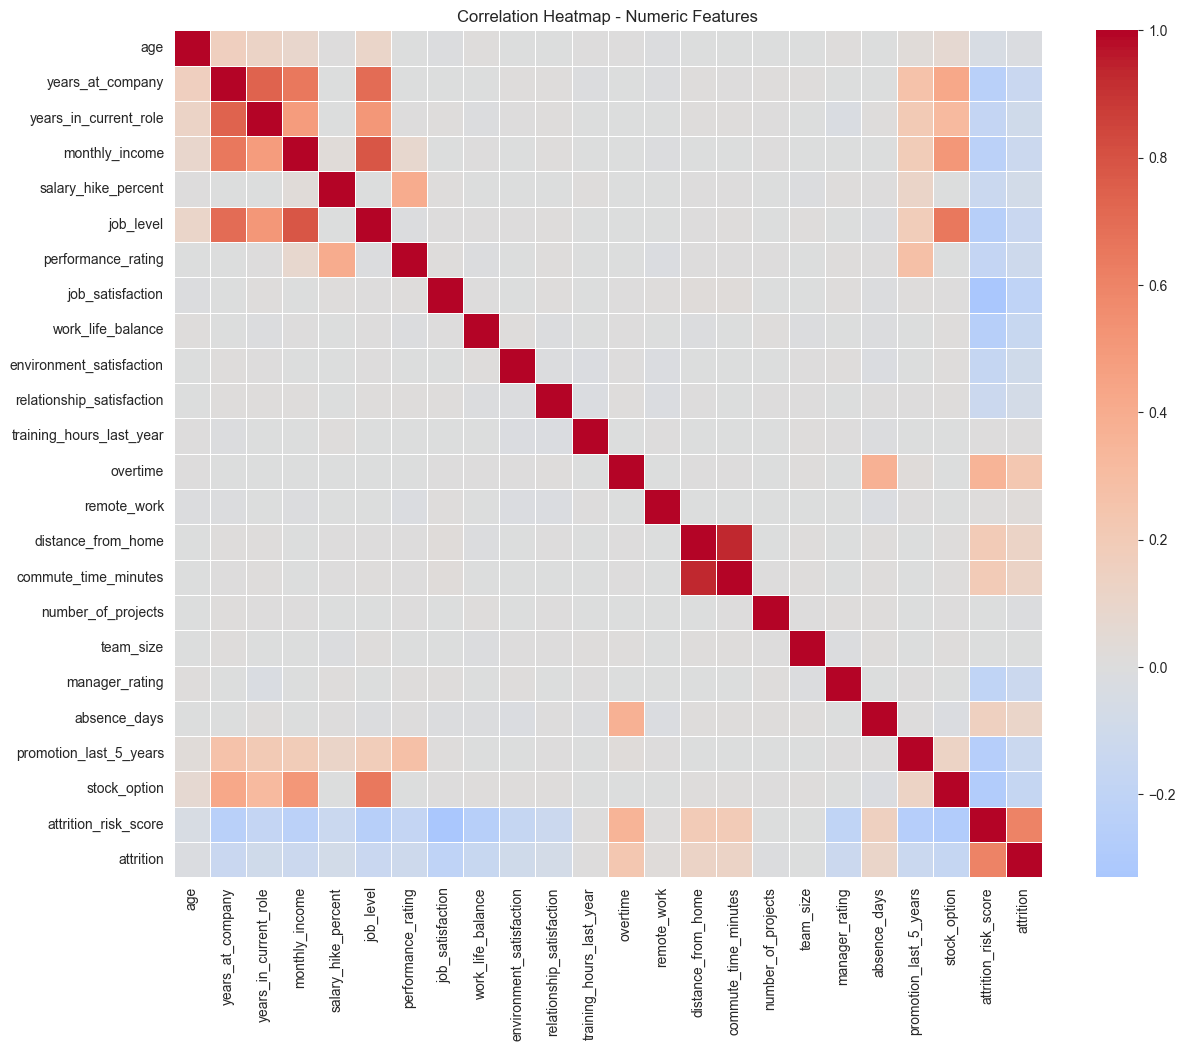


Correlation with Attrition (ranked by strength):
attrition_risk_score         0.603
overtime                     0.226
job_satisfaction            -0.204
stock_option                -0.166
work_life_balance           -0.150
job_level                   -0.146
years_at_company            -0.144
promotion_last_5_years      -0.135
monthly_income              -0.132
manager_rating              -0.125
commute_time_minutes         0.125
distance_from_home           0.124
absence_days                 0.110
performance_rating          -0.110
years_in_current_role       -0.101
environment_satisfaction    -0.097
salary_hike_percent         -0.086
relationship_satisfaction   -0.074
age                         -0.022
remote_work                  0.021
number_of_projects          -0.012
training_hours_last_year     0.004
team_size                   -0.001
Name: attrition, dtype: float64


In [10]:
numeric_cols = [
    "age", "years_at_company", "years_in_current_role", "monthly_income",
    "salary_hike_percent", "job_level", "performance_rating",
    "job_satisfaction", "work_life_balance", "environment_satisfaction",
    "relationship_satisfaction", "training_hours_last_year", "overtime",
    "remote_work", "distance_from_home", "commute_time_minutes",
    "number_of_projects", "team_size", "manager_rating", "absence_days",
    "promotion_last_5_years", "stock_option", "attrition_risk_score",
    "attrition"
]
 
correlation = df[numeric_cols].corr()
 
plt.figure(figsize=(14, 11))
sns.heatmap(correlation, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()
 
attrition_corr = correlation["attrition"].drop("attrition").sort_values(key=abs, ascending=False)
print("\nCorrelation with Attrition (ranked by strength):")
print(attrition_corr.round(3))

Insight:The attrition risk score (0.60) is by far the strongest correlate with attrition, which is expected since it is a derived score; this should be verified against how the score was originally constructed to rule out target leakage before it is used in the predictive model. Among the raw features, overtime (+0.23) and job satisfaction (-0.20) are the strongest independent predictors, followed by stock option, work-life balance, job level, years at company, promotion history, and monthly income, all in the range of roughly -0.13 to -0.17. Training hours, teamsize, and number of projects show almost no linear relationship with attrition, each below 0.02 in magnitude.

Outlier Check

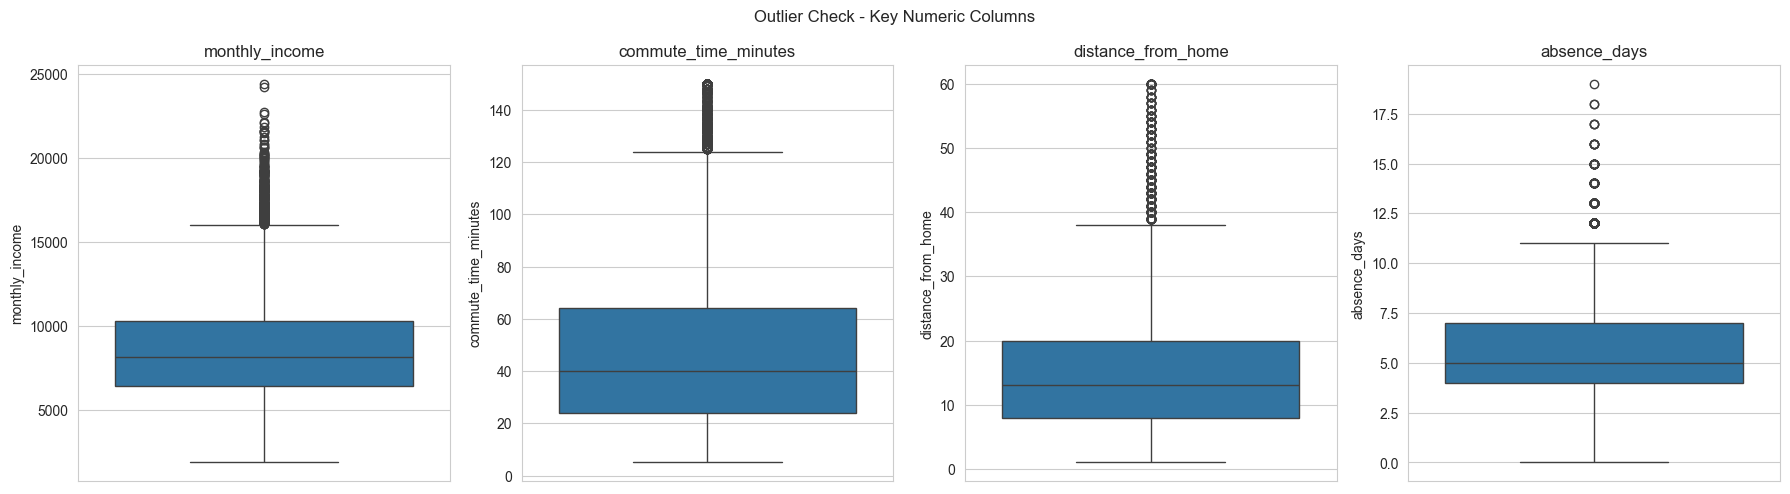


Outlier count (IQR method):
monthly_income: 320 outliers (2.13%)
commute_time_minutes: 536 outliers (3.57%)
distance_from_home: 439 outliers (2.93%)
absence_days: 313 outliers (2.09%)


In [11]:
outlier_cols = ["monthly_income", "commute_time_minutes", "distance_from_home", "absence_days"]
 
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.suptitle("Outlier Check - Key Numeric Columns")
plt.tight_layout()
plt.show()
 
print("\nOutlier count (IQR method):")
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers / len(df) * 100:.2f}%)")

Insight:Outliers are minimal across all four columns checked, ranging from 2.09% to 3.57% of records, and reflect natural extreme values, such as unusually long commutes, rather than data-entry errors. No capping or removal is necessary at this stage of the analysis.

Executive Summary:
Overall attrition stands at 32.3%, roughly one in every three employees. The strongest and most actionable drivers are a lack of promotion, overtime, low job satisfaction, poor work-life balance, contract employment status, and frequent business travel. Attrition skews toward early-career employees, with those who left averaging a tenure of roughly two years against four for those who stayed. Department-level differences are minor, indicating an organization-wide issue, but specific job roles, particularly Quality Analyst, Training Specialist, and Operations Executive, show meaningfully higher risk and are reasonable starting points for a targeted retention effort. Compensation plays a moderate role: absolute income shows a real gap between leavers and stayers, while the size of a recent raise does not. The dataset's built-in attrition risk score is strongly validated by this analysis and is a strong candidate feature for the predictive model in the next phase, pending confirmation that it was not derived from attrition data itself. Data quality overall is solid, with no missing values, no duplicate records, and minimal outliers across the numeric columns reviewed.